# Titulo: Laboratorio  4
# Fecha: 22 de mayo
# Autor: Elizabeth Vega Pacheco
# Exploración de Datos

## Objetivo

Aplicar técnicas de limpieza y preparación de datos para identificar y corregir valores faltantes, registros duplicados y errores de formato, con el fin de mejorar la calidad de la información antes de realizar análisis posteriores.

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
#Cargamos el dataset crudo/sucio
dfCrudo = pd.read_csv("../DataSet/dataset_sucio_practica.csv")

In [5]:
dfCrudo

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
...,...,...,...,...,...,...,...,...
120,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
121,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
122,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
123,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No


In [23]:
dfCrudocopia = dfCrudo.copy()

In [24]:
dfCrudoCopia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              120 non-null    int64  
 1   nombre          112 non-null    object 
 2   edad            74 non-null     float64
 3   correo          120 non-null    object 
 4   pais            78 non-null     object 
 5   salario         104 non-null    float64
 6   fecha_registro  120 non-null    object 
 7   activo          86 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 8.4+ KB


In [25]:
dfCrudoCopia.describe()

,id,edad,salario
count,120.000000,74.000000,104.000000
mean,60.500000,30.527027,13778.846154
std,34.785054,6.050525,8752.205526
min,1.000000,22.000000,-1000.000000
25%,30.750000,25.000000,12000.000000
50%,60.500000,30.000000,15000.000000
75%,90.250000,35.000000,18000.000000
max,120.000000,40.000000,25000.000000


In [26]:
dfCrudocopia.isnull().sum()

id                 0
nombre             9
edad              15
correo             0
pais              43
salario           18
fecha_registro     0
activo            35
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

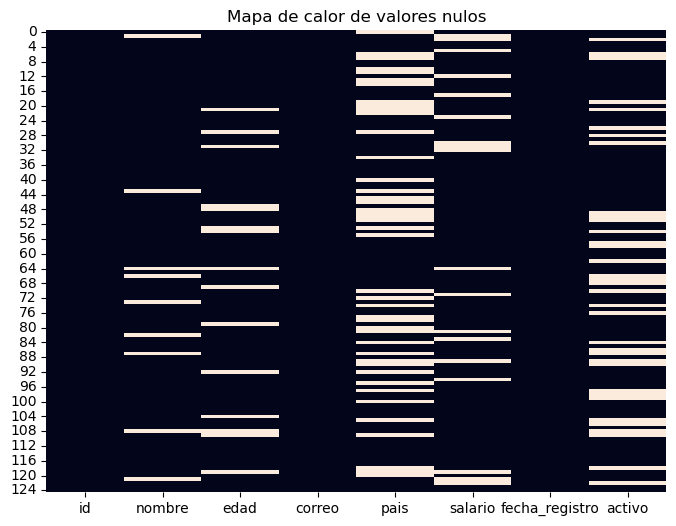

In [27]:
plt.figure ( figsize=(8,6))
sns.heatmap(dfCrudocopia.isnull(), cbar=False)
plt.title("Mapa de calor de valores nulos")
plt.show

#limpieza de datos 
1 eliminar datos duplicados
2 imputar valores nulos
3 corregir outlier (valores fuera del rango)

In [28]:
#eliminamos datos duplicados
dfCrudoCopia.duplicated().sum()

np.int64(0)

In [29]:
dfCrudoCopia.drop_duplicates(inplace=True)#elimina datos duplicados

In [30]:
dfCrudoCopia.duplicated().sum()

np.int64(0)

In [31]:
#verificamos la existencia de edades fuera de rango
dfCrudoCopia[
    (dfCrudoCopia["edad"]<0 )|(dfCrudoCopia["edad"]>100)
    ]


,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [32]:
#convertimos las edades invalidas en NaN
dfCrudoCopia.loc[
    (dfCrudoCopia["edad"]<0 )|(dfCrudoCopia["edad"]>100),"edad"
    ] =np.nan

In [33]:
#verificamos la existencia de edades fuera de rango
dfCrudocopia[
    (dfCrudocopia["edad"]<0 ) |(dfCrudocopia["edad"]>100)
]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
6,7,Roberto Smith,-5.0,vegasara@yahoo.com,NaN,12000.0,2026-03-31,NaN
7,8,Nicholas Torres,-5.0,arnoldjoe@macias.biz,NaN,12000.0,2026-04-07,NaN
9,10,Angela Richards,-5.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
12,13,Paul Liu,150.0,ilong@gmail.com,España,NaN,2025-11-21,No
16,17,Christopher Klein,-5.0,ericarice@hotmail.com,España,18000.0,2024-09-22,Sí
22,23,Mrs. Diane Carter,150.0,schultzpatrick@mccoy.net,NaN,18000.0,2024-10-31,No
23,24,Vicki Love,-5.0,antonio14@johnson.net,Argentina,NaN,2026-01-24,No
24,25,Matthew Porter,-5.0,hansoncameron@yahoo.com,Argentina,12000.0,2025-11-17,No


In [34]:
#calculamos la mediana del campo edad
mediana_edad = dfCrudoCopia["edad"].median()
mediana_edad

30.0

In [35]:
 dfCrudoCopia["edad"]= dfCrudoCopia["edad"].fillna(mediana_edad)

In [36]:
 dfCrudoCopia["edad"].describe()

count    120.000000
mean      30.325000
std        4.745918
min       22.000000
25%       30.000000
50%       30.000000
75%       31.250000
max       40.000000
Name: edad, dtype: float64

In [37]:
#verificamos los salarios negativos
dfCrudoCopia[
    (dfCrudoCopia["salario"]<0 )
    ]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
9,10,Angela Richards,30.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
11,12,Daniel Wright,25.0,melissamaxwell@gmail.com,NaN,-1000.0,2024-12-20,Sí
20,21,Marc Miller DDS,30.0,ccalderon@campbell-carter.com,NaN,-1000.0,2024-06-25,Sí
21,22,Carrie Griffith,30.0,correo_invalido,NaN,-1000.0,2025-05-05,NaN
26,27,Mary Miranda,40.0,brendaglenn@gmail.com,Argentina,-1000.0,2025-06-01,NaN
27,28,John Taylor,30.0,jonesashley@hotmail.com,NaN,-1000.0,2025-08-02,No
28,29,Teresa Ramos,22.0,rileyraymond@hotmail.com,México,-1000.0,2025-08-29,NaN
37,38,Brian Sherman,30.0,brianna61@yahoo.com,Argentina,-1000.0,2024-09-17,Sí
41,42,Patricia Morrison,30.0,uweiss@yahoo.com,Argentina,-1000.0,2026-03-10,No
44,45,John Estrada,35.0,nichole26@hotmail.com,Argentina,-1000.0,2025-12-12,Sí


In [38]:
#convertimos los salarios invalidas en NaN
dfCrudoCopia.loc[
    (dfCrudoCopia["salario"]<0 ),"salario"
    ] =np.nan

In [39]:
#verificamos la existencia de edades fuera de rango
dfCrudoCopia[
    (dfCrudoCopia["salario"]<0 )
]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [40]:
mediana_salario = dfCrudoCopia["salario"].median()
mediana_salario

15000.0

In [41]:
mediana_salario=1500

In [42]:
dfCrudocopia["salario"]= dfCrudocopia["salario"].fillna(mediana_salario)

In [43]:
dfCrudoCopia["salario"].describe()

count       83.000000
mean     17518.072289
std       5111.826187
min      12000.000000
25%      12000.000000
50%      15000.000000
75%      25000.000000
max      25000.000000
Name: salario, dtype: float64

In [44]:
dfCrudocopia[
    ~dfCrudocopia["correo"].str.contains("@", na=False)
    ]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
18,19,Nicholas Curry,35.0,correo_invalido,México,12000.0,2025-11-22,Sí
21,22,Carrie Griffith,NaN,correo_invalido,NaN,-1000.0,2025-05-05,NaN
30,31,Mrs. Sara Johnson,35.0,correo_invalido,Argentina,1500.0,2026-03-07,NaN
40,41,Cynthia Arnold,150.0,correo_invalido,NaN,25000.0,2024-11-03,No
65,66,Michael Lopez,40.0,correo_invalido,España,-1000.0,2025-12-01,No
78,79,Charles Page,25.0,correo_invalido,NaN,-1000.0,2025-09-01,No
87,88,NaN,22.0,correo_invalido,NaN,12000.0,2025-03-07,NaN
88,89,Erika Bernard,150.0,correo_invalido,Argentina,12000.0,2024-11-16,Sí


In [45]:
correos_invalidos = ~dfCrudocopia["correo"].str.contains("@", na=False)
correos_invalidos

0      False
1      False
2      False
3       True
4       True
       ...  
120    False
121    False
122    False
123     True
124     True
Name: correo, Length: 125, dtype: bool

In [46]:
dfCrudocopia.loc[correos_invalidos, "correo"] = pd.NA

In [47]:
dfCrudocopia["correo_valido"] = dfCrudocopia["correo"].str.contains("@", na=False)

In [48]:
dfCrudocopia.head(5)

,id,nombre,edad,correo,pais,salario,fecha_registro,activo,correo_valido
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí,True
1,2,NaN,35.0,asimmons@garza.com,España,1500.0,2026-05-04,No,True
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,1500.0,2026-01-27,NaN,True
3,4,Joyce Williams,30.0,<NA>,Argentina,25000.0,2025-02-23,No,False
4,5,Elaine Sanchez,-5.0,<NA>,México,25000.0,2025-03-28,Sí,False


In [49]:
dfCrudocopia["pais"].isnull().sum()

np.int64(43)

In [50]:
pais_moda = dfCrudocopia["pais"].mode()[0]

In [51]:
dfCrudocopia["pais"] = dfCrudocopia["pais"].fillna(pais_moda)

In [52]:
dfCrudocopia["pais"].isnull().sum()

np.int64(0)

In [53]:
dfCrudocopia.dtypes

id                  int64
nombre             object
edad              float64
correo             object
pais               object
salario           float64
fecha_registro     object
activo             object
correo_valido        bool
dtype: object

In [54]:
dfCrudocopia["fecha_registro"] = pd.to_datetime(dfCrudocopia["fecha_registro"])

In [55]:
dfCrudocopia["fecha_registro"].dtype

dtype('<M8[ns]')

In [56]:
dfCrudocopia.dtypes

id                         int64
nombre                    object
edad                     float64
correo                    object
pais                      object
salario                  float64
fecha_registro    datetime64[ns]
activo                    object
correo_valido               bool
dtype: object

In [57]:
dfCrudocopia["activo"].value_counts(dropna=False)

activo
Sí     49
No     41
NaN    35
Name: count, dtype: int64

In [58]:
dfCrudocopia["activo"] = dfCrudocopia["activo"].fillna("Sí")

In [59]:
dfCrudocopia["activo"].value_counts(dropna=False)

activo
Sí    84
No    41
Name: count, dtype: int64

In [60]:
dfCrudocopia["activo"] = dfCrudocopia["activo"].map(
    {
        "Sí": 1,
        "No": 0
    })

In [61]:
dfCrudocopia["activo"].value_counts(dropna=False)

activo
1    84
0    41
Name: count, dtype: int64

# CONCLUSIONES
#1. Importancia de trabajar sobre una copia del dataset
#2. Detección y eliminación de duplicados
#3. Tratamiento de valores fuera de rango (outliers)
## Interpretación de Resultados

La limpieza de datos es una etapa fundamental para garantizar análisis confiables y consistentes.